In [112]:
import numpy as np 
import matplotlib.pyplot  as plt

In [113]:
x = [50, 60, 70, 80, 90]
y = [150, 180, 210, 240, 270] 
print(f"type of x : {type(x)}")
print(f"type of y: {type(y)}")

type of x : <class 'list'>
type of y: <class 'list'>


In [114]:
x=np.array(x)
y=np.array(y)
print(f"type of x : {type(x)}")
print(f"type of y: {type(y)}")

type of x : <class 'numpy.ndarray'>
type of y: <class 'numpy.ndarray'>


In [115]:
class LinearRegressionGD ():
    def __init__(self,eta=0.0001,epochs=10):
        self.eta=eta
        self.epochs=epochs
        self.theta_0=0
        self.theta_1=0
        self.sse_values = []

    def fit(self,x,y):
        n_sample=len(x)
        self.sse_values = []

        for _ in range(self.epochs):
            y_hat=self.theta_0*x+self.theta_1

            sse = np.sum((y_hat - y) ** 2)
            self.sse_values.append(sse)

            dw=(1/n_sample)*np.sum((y_hat-y)*x)
            db=(1/n_sample)*np.sum(y_hat-y)

            self.theta_1 -= self.eta * dw
            self.theta_0 -= self.eta * db


In [116]:
eta=0.001  
epochs=100

model=LinearRegressionGD(eta,epochs)

model.fit(x,y)

w=model.theta_0
b=model.theta_1

print(f"value of theta_0: {w}")
print(f"value of theta_1: {b}")

value of theta_0: 1.2722951898501635
value of theta_1: 123.38275127307547


In [117]:
#What do theta_0 and theta_1 represent in the regression equation? 
#theta_0 and theta_1 are the parameters we continuously optimize until we achieve a best-fit line for the data, with theta_0 determining the direction of the line and theta_1 providing the shift.

In [118]:
y_pred = model.theta_0 * 70 + model.theta_1
print(f"Predicted price for 70 m²: {y_pred}")

Predicted price for 70 m²: 212.44341456258692


In [119]:
#Is the prediction reasonable based on the dataset? Why? 
#Yes, the prediction makes total sense because 70 is already part of our x dataset, and its actual value in y is 210 
#So, the expected figure had to be close to 210, and it came out to 212

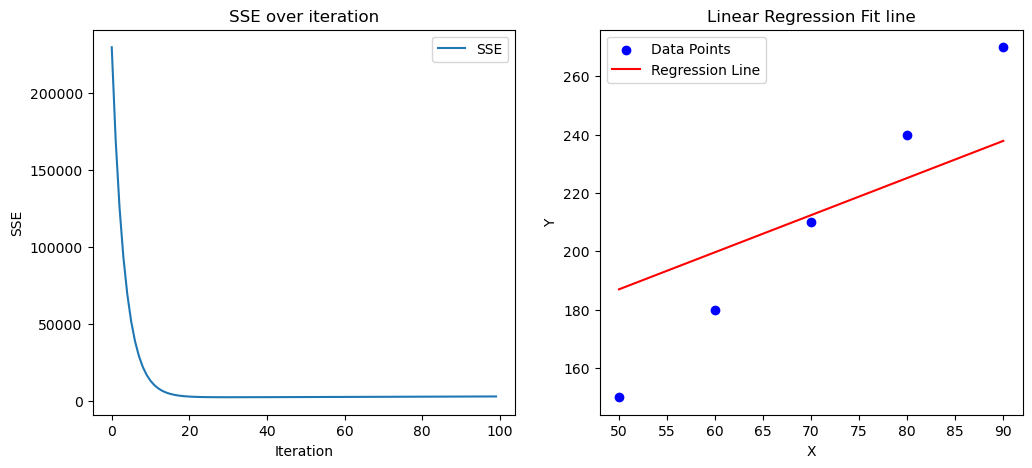

In [120]:
num_iteration = model.epochs
sse_values = model.sse_values

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(num_iteration), sse_values, label='SSE')
plt.xlabel("Iteration")
plt.ylabel('SSE')
plt.title('SSE over iteration')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x, y, color="blue", label='Data Points')
plt.plot(x, b + w * x, color='red', label='Regression Line')
plt.xlabel("X")
plt.ylabel('Y')
plt.title("Linear Regression Fit line")
plt.legend()
plt.show()

In [121]:
#Why SSE decreases over time ? 
#Initially, the model starts with random parameters, resulting in a high cost; the weights are positioned high on the curve. As the gradient is calculated, the cost decreases, causing the model to descend.

#What convergence means in Gradient Descent ?
#When the tangent is flate

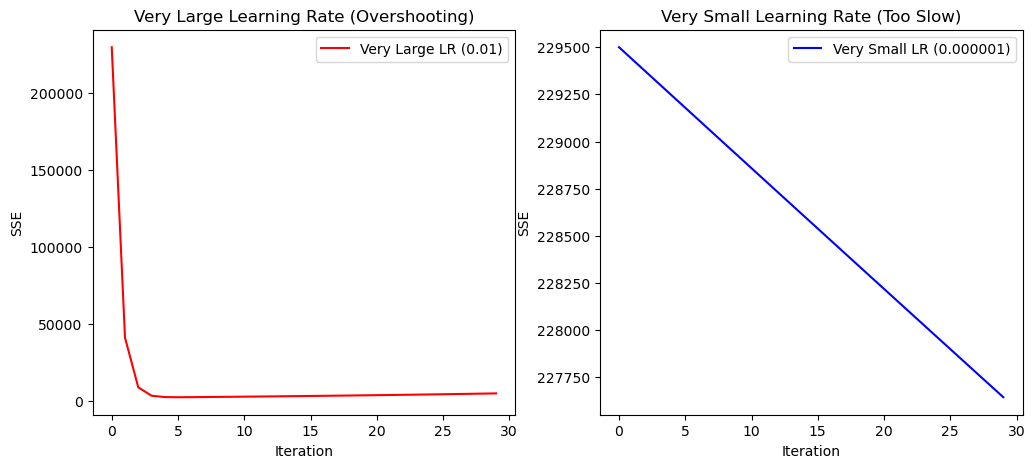

In [122]:
model_large = LinearRegressionGD(eta=0.1, epochs=50)
model_large.fit(x, y)

model_small = LinearRegressionGD(eta=0.000001, epochs=50)
model_small.fit(x, y)

model_large = LinearRegressionGD(eta=0.01, epochs=30)
model_large.fit(x, y)

model_small = LinearRegressionGD(eta=0.000001, epochs=30)
model_small.fit(x, y)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(model_large.epochs), model_large.sse_values, color='red', label='Very Large LR (0.01)')
plt.xlabel("Iteration")
plt.ylabel('SSE')
plt.title('Very Large Learning Rate (Overshooting)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(model_small.epochs), model_small.sse_values, color='blue', label='Very Small LR (0.000001)')
plt.xlabel("Iteration")
plt.ylabel('SSE')
plt.title('Very Small Learning Rate (Too Slow)')
plt.legend()

plt.show()




In [123]:
#What happens if the learning rate is too large? 
#It will happen over shooting 